# Image Dataset Analysis and Annotation Exploration

This notebook provides a comprehensive analysis of an image dataset, focusing on various aspects such as image properties, annotations, and feature engineering. The workflow includes:

1. **Data Loading and Preprocessing**:
    - Loading training and validation datasets.
    - Combining image metadata and annotations for unified analysis.

2. **Image Feature Analysis**:
    - Exploring image dimensions, sizes, brightness, and other properties.
    - Visualizing distributions and identifying outliers.

3. **Scene and Weather Analysis**:
    - Analyzing the distribution of image scenes and weather conditions.
    - Visualizing images from underrepresented categories.

4. **Annotation Analysis**:
    - Examining bounding box properties such as height, width, and area.
    - Investigating occlusion and truncation in annotations.
    - Visualizing bounding boxes and categories on sample images.

5. **Feature Engineering**:
    - Creating new features like bounding box area.
    - Merging image metadata with annotation data for enriched analysis.

6. **Category-Level Insights**:
    - Analyzing category distributions and unique image counts.
    - Exploring annotations for specific categories like cars, buses, and more.

This notebook serves as a guide for understanding the dataset, identifying potential issues, and preparing the data for downstream tasks such as model training or further analysis.


## Analysis
1. There is no discrepancy in val and train splits.
2. All images are of same size 1280x640
3. Mostly images are captured in clear conditions. Should include more samples from different weather condition.
4. Mostly samples are from city street view.
5. Data contains large number of car samples, with very few samples of train and truck. Truck, Bus, bike, rider, motor and train contributes less than 5% of total annotations.
6. Traffic sign and traffic light has small bbox as compared to other classes.Truck and bus as comparitively large bboxes. We need to be carefully in choosing anchor size in models.
7. Large number of cars are occluded.
8. Mostly cars are truncated, hence we should include more samples of other classes.

In [ ]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import sys

sys.path.append("..")

In [2]:
def display_images(image_paths, title="Image Grid", img_dir="path_to_images", num_cols=5):
    """
    Display images in a grid with a specified number of columns.

    Parameters:
    - image_paths: List of image file names to display.
    - title: Title of the image grid.
    - img_dir: Directory where the images are stored.
    - num_cols: Number of images per row.
    """
    num_images = len(image_paths)
    num_rows = (num_images + num_cols - 1) // num_cols  # Calculate rows needed

    plt.figure(figsize=(15, num_rows * 3))
    for i, image_name in enumerate(image_paths):
        image_path = os.path.join(img_dir, image_name)
        img = plt.imread(image_path)
        plt.subplot(num_rows, num_cols, i + 1)
        plt.imshow(img)
        plt.title(os.path.basename(image_name), fontsize=10)
        plt.axis("off")

    plt.suptitle(title, fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

## load train and validation csvs and combine them

In [ ]:

train_img_features_csv  =  "./data/train/image_features.csv"
train_img_dir = "./data/bdd100k_images_100k/bdd100k/images/100k/train"
val_img_features_csv  =  "./data/val/image_features.csv"
val_img_dir = "./data/bdd100k_images_100k/bdd100k/images/100k/val"

train_img_df = pd.read_csv(train_img_features_csv)
print("train_img_df.shape", train_img_df.shape)
train_img_df["split"] = "train"
train_img_df["image_path"] = train_img_df["image_name"].apply(lambda x: os.path.join(train_img_dir, x))

val_img_df = pd.read_csv(val_img_features_csv)
val_img_df["split"] = "val"
val_img_df["image_path"] = val_img_df["image_name"].apply(lambda x: os.path.join(val_img_dir, x))
print("val_img_df.shape", val_img_df.shape)
img_df = pd.concat([train_img_df, val_img_df], axis=0, ignore_index=True)
print("img_df.shape", img_df.shape)

train_img_df.shape (69863, 12)
val_img_df.shape (10000, 14)
img_df.shape (79863, 14)


Total training images : 69863  
Total val images : 10000

## image feature analysis

In [111]:
img_df.describe()

,image_width,image_height,brightness,sharpness,contrast,size(MBs)
count,79863.0,79863.0,79863.000000,79863.000000,79863.000000,79863.000000
mean,1280.0,720.0,74.218360,4.098572,49.866779,0.055301
std,0.0,0.0,39.587076,2.266222,17.107697,0.018333
min,1280.0,720.0,0.237934,0.083234,3.718682,0.016200
25%,1280.0,720.0,33.125619,2.163793,35.183853,0.039700
50%,1280.0,720.0,87.023147,3.872026,54.817003,0.054300
75%,1280.0,720.0,105.741405,5.753156,63.337655,0.069100
max,1280.0,720.0,250.383563,20.098019,93.258212,0.143900


In [112]:
img_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79863 entries, 0 to 79862
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   image_width      79863 non-null  int64  
 1   image_height     79863 non-null  int64  
 2   brightness       79863 non-null  float64
 3   sharpness        79863 non-null  float64
 4   contrast         79863 non-null  float64
 5   rgb_mean         79863 non-null  object 
 6   rgb_std          79863 non-null  object 
 7   size(MBs)        79863 non-null  float64
 8   image_name       79863 non-null  object 
 9   image_weather    79863 non-null  object 
 10  image_scene      79863 non-null  object 
 11  image_timeofday  79863 non-null  object 
 12  split            79863 non-null  object 
 13  image_path       79863 non-null  object 
dtypes: float64(4), int64(2), object(8)
memory usage: 8.5+ MB


All data is valid

### 1.1 Image Height and Width scatterplot

Text(0.5, 1.0, 'width-height distribution')

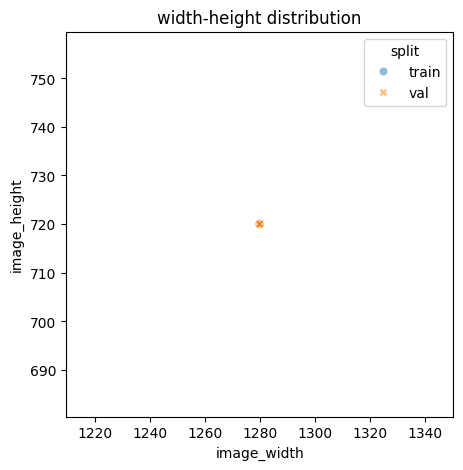

In [113]:
plt.figure(figsize=(5,5))
# filtered_df = combined_df.groupby(["image_name",])[["width","height"]].agg("mean")
ax = sns.scatterplot(data = img_df,x="image_width",y = "image_height",hue="split",style="split",markers={"train":"o","val":"X"},alpha=0.5,)
for i in ax.containers:
    ax.bar_label(i,)
ax.set_title("width-height distribution")

### img size analysis

C:\Users\AmanGupta\AppData\Local\Temp\ipykernel_15460\2793000229.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=img_df, x="split", y="size(MBs)", palette="mako", ax=axes[1])


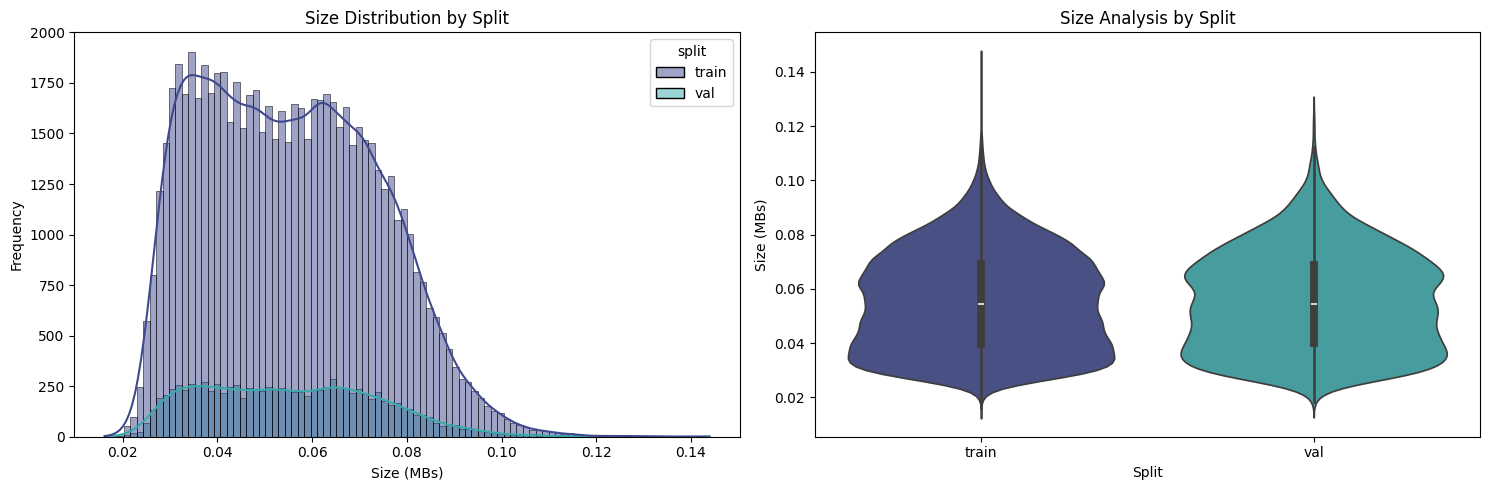

In [74]:
# Side-by-side displot
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Displot for size distribution
sns.histplot(data=img_df, x="size(MBs)", hue="split", kde=True, ax=axes[0], palette="mako")
axes[0].set_title("Size Distribution by Split")
axes[0].set_xlabel("Size (MBs)")
axes[0].set_ylabel("Frequency")

# Violin plot for mean and quartile analysis
sns.violinplot(data=img_df, x="split", y="size(MBs)", palette="mako", ax=axes[1])
axes[1].set_title("Size Analysis by Split")
axes[1].set_xlabel("Split")
axes[1].set_ylabel("Size (MBs)")

plt.tight_layout()
plt.show()

1. Both Train and Val has same distribution  
2. IQR lies between 0.039 to 0.069 MB

### Plot images which are size outliers


Number of outliers: 1535


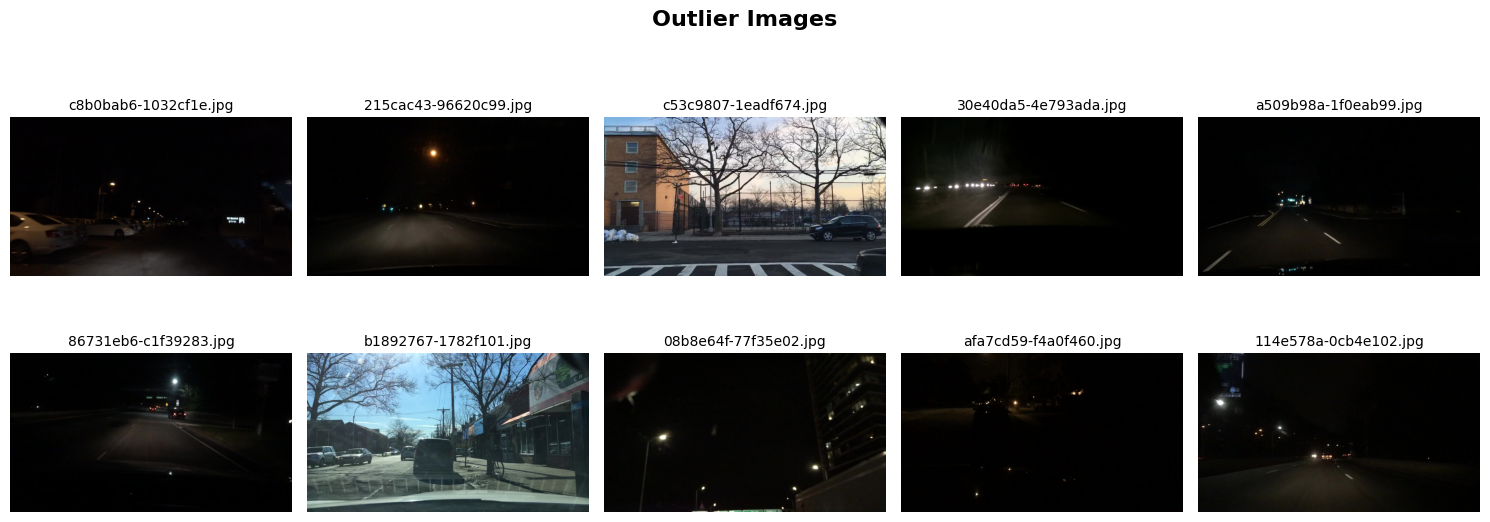

In [118]:
# Define outlier thresholds
lower_threshold = img_df["size(MBs)"].quantile(0.01)  # Bottom 1%
upper_threshold = img_df["size(MBs)"].quantile(0.99)  # Top 1%

# Filter outliers
outliers = img_df[(img_df["size(MBs)"] < lower_threshold) | (img_df["size(MBs)"] > upper_threshold)]

# Display outlier images
print(f"Number of outliers: {len(outliers)}")
outlier_images = outliers["image_path"].unique()

total_imgs_to_show = 10
if len(outlier_images) > total_imgs_to_show:
    outlier_images = np.random.choice(outlier_images, total_imgs_to_show, replace=False)

display_images(outlier_images, title="Outlier Images", num_cols=5)

#### 1.3 Image brighness, contrast and sharpess value distribution

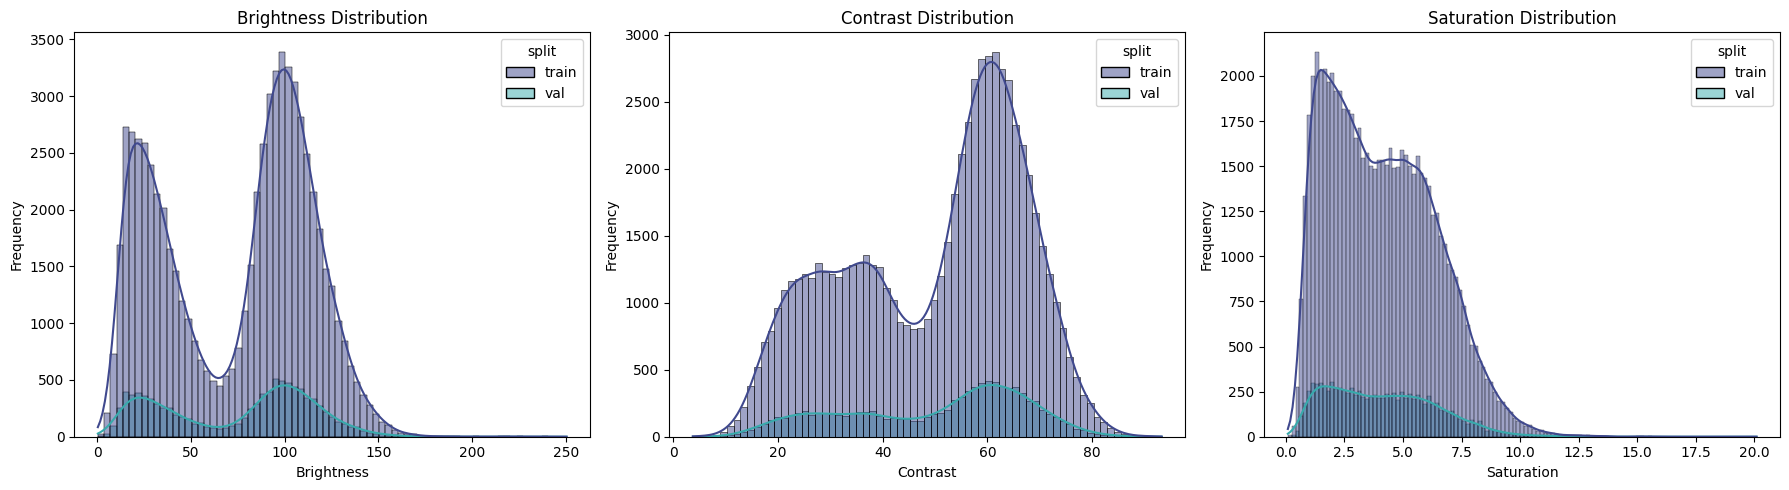

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

# Brightness distribution
sns.histplot(data=img_df, x="brightness", hue="split", kde=True, ax=axes[0], palette="mako")
axes[0].set_title("Brightness Distribution")
axes[0].set_xlabel("Brightness")
axes[0].set_ylabel("Frequency")

# Contrast distribution
sns.histplot(data=img_df, x="contrast", hue="split", kde=True, ax=axes[1], palette="mako")
axes[1].set_title("Contrast Distribution")
axes[1].set_xlabel("Contrast")
axes[1].set_ylabel("Frequency")

# Saturation distribution
sns.histplot(data=img_df, x="sharpness", hue="split", kde=True, ax=axes[2], palette="mako")
axes[2].set_title("sharpness Distribution")
axes[2].set_xlabel("sharpness")
axes[2].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

#### Plot images from brightness bimodal distribution

Number of filtered images: 28623


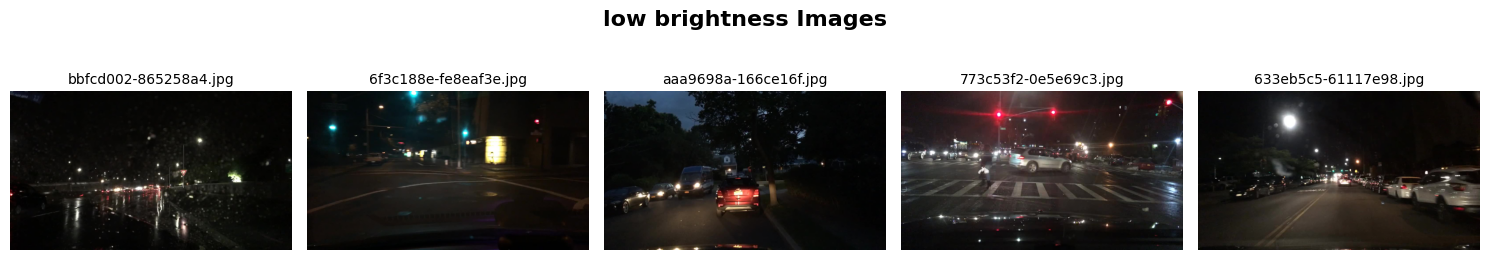

In [ ]:
# Define outlier thresholds
lower_threshold  = 50
filtered_df = img_df[(img_df["brightness"] < lower_threshold)]

# Display outlier images
print(f"Number of filtered images: {len(filtered_df)}")
filtered_images = filtered_df["image_path"].unique()

total_imgs_to_show = 10
if len(filtered_images) > total_imgs_to_show:
    filtered_images = np.random.choice(filtered_images, total_imgs_to_show, replace=False)

display_images(filtered_images, title="low brightness Images", num_cols=5)

Number of filtered images: 44307


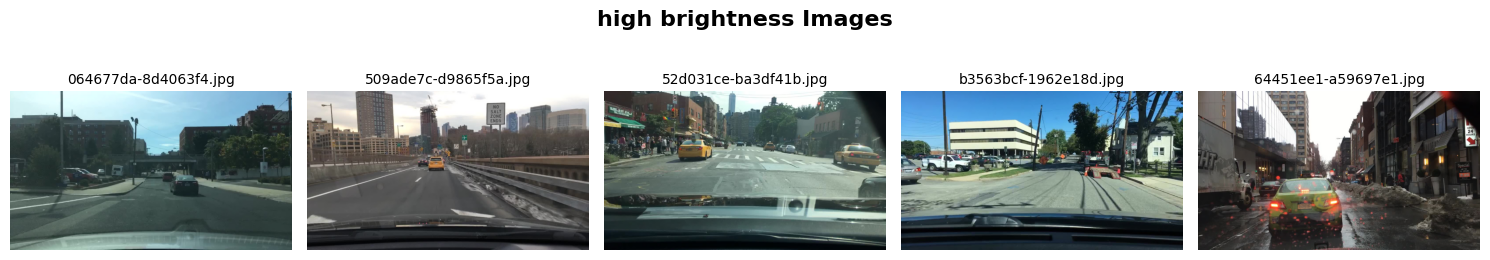

In [123]:
# Define outlier thresholds
lower_threshold  = 80
filtered_df = img_df[(img_df["brightness"] > lower_threshold)]

# Display outlier images
print(f"Number of filtered images: {len(filtered_df)}")
filtered_images = filtered_df["image_path"].unique()

total_imgs_to_show = 5
if len(filtered_images) > total_imgs_to_show:
    filtered_images = np.random.choice(filtered_images, total_imgs_to_show, replace=False)

display_images(filtered_images, title="high brightness Images", num_cols=5)

Number of outliers: 1598


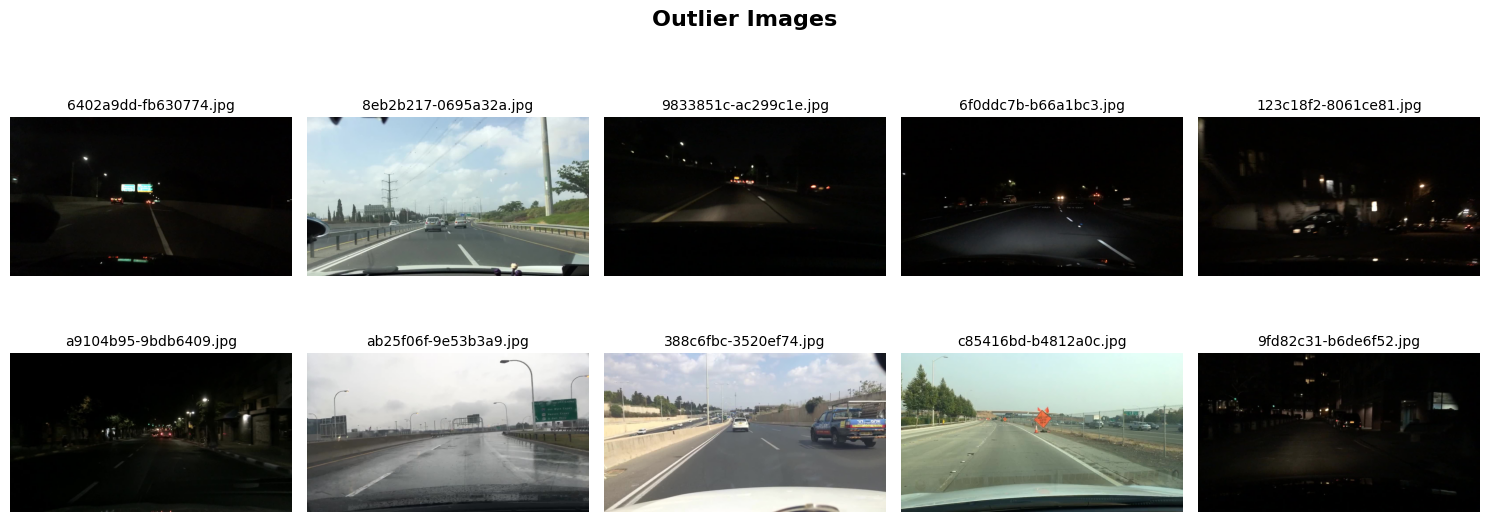

In [124]:
# Define outlier thresholds
lower_threshold = img_df["brightness"].quantile(0.01)  # Bottom 1%
upper_threshold = img_df["brightness"].quantile(0.99)  # Top 1%

# Filter outliers
outliers = img_df[(img_df["brightness"] < lower_threshold) | (img_df["brightness"] > upper_threshold)]

# Display outlier images
print(f"Number of outliers: {len(outliers)}")
outlier_images = outliers["image_path"].unique()

total_imgs_to_show = 10
if len(outlier_images) > total_imgs_to_show:
    outlier_images = np.random.choice(outlier_images, total_imgs_to_show, replace=False)

display_images(outlier_images, title="Outlier Images", num_cols=5)

#### 2.1 weather condition Distribution

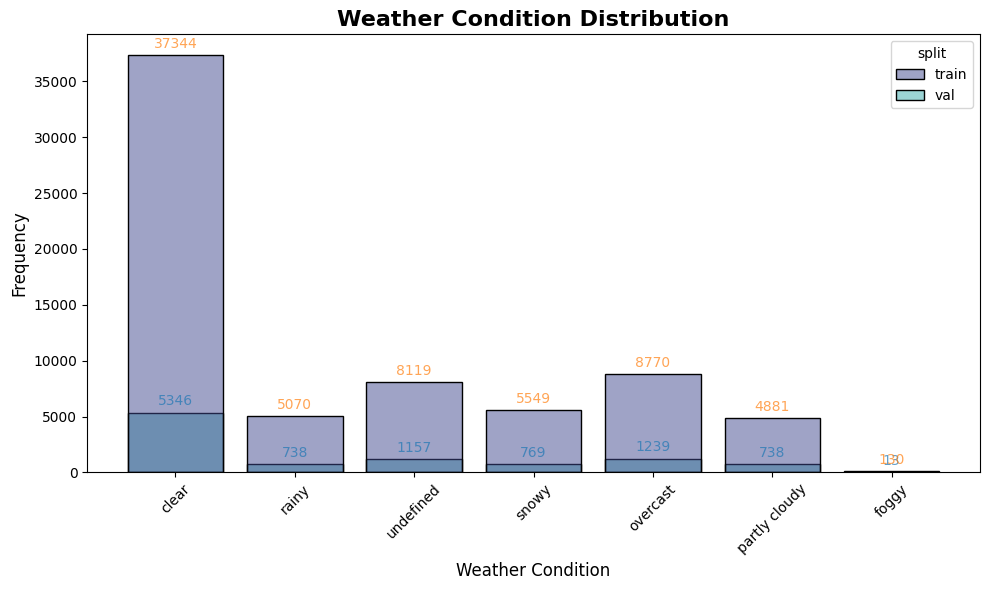

In [66]:
plt.figure(figsize=(10, 6))

ax = sns.histplot(data=img_df, x="image_weather", hue="split", shrink=0.8, palette="mako", kde=False)
for container, hue_value in zip(ax.containers, img_df["split"].unique()):
    ax.bar_label(container, fmt='%d', label_type='edge', fontsize=10, padding=3, color=sns.color_palette("tab10")[list(img_df["split"].unique()).index(hue_value)], alpha=0.7)

ax.set_title("Weather Condition Distribution", fontsize=16, fontweight='bold')
ax.set_xlabel("Weather Condition", fontsize=12)
ax.set_ylabel("Frequency", fontsize=12)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

Mostly images are captured in clear conditions. Should include more samples from different weather condition.

### image scene

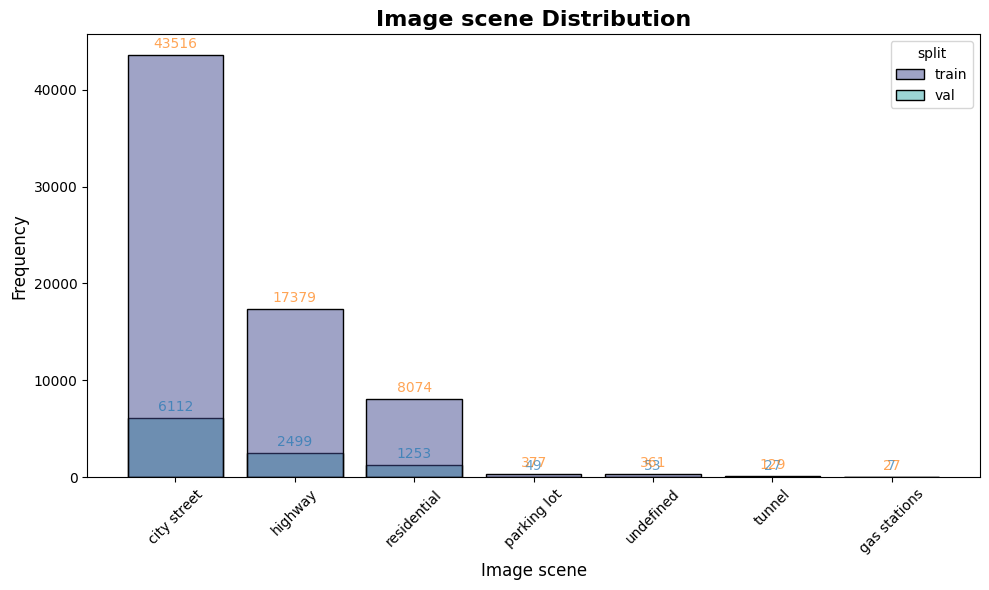

In [67]:
plt.figure(figsize=(10, 6))

ax = sns.histplot(data=img_df, x="image_scene",hue="split", shrink=0.8, palette="mako", kde=False)
for container, hue_value in zip(ax.containers, img_df["split"].unique()):
    ax.bar_label(container, fmt='%d', label_type='edge', fontsize=10, padding=3, color=sns.color_palette("tab10")[list(img_df["split"].unique()).index(hue_value)], alpha=0.7)

ax.set_title("Image scene Distribution", fontsize=16, fontweight='bold')
ax.set_xlabel("Image scene", fontsize=12)
ax.set_ylabel("Frequency", fontsize=12)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

1. The data is unevenly distibuted for image scene. We have very less number of samples for parking lot, tunnel and gas station.
2. Mostly samples belongs to city street view

#### checking different image scene images

Number of filtered images: 426


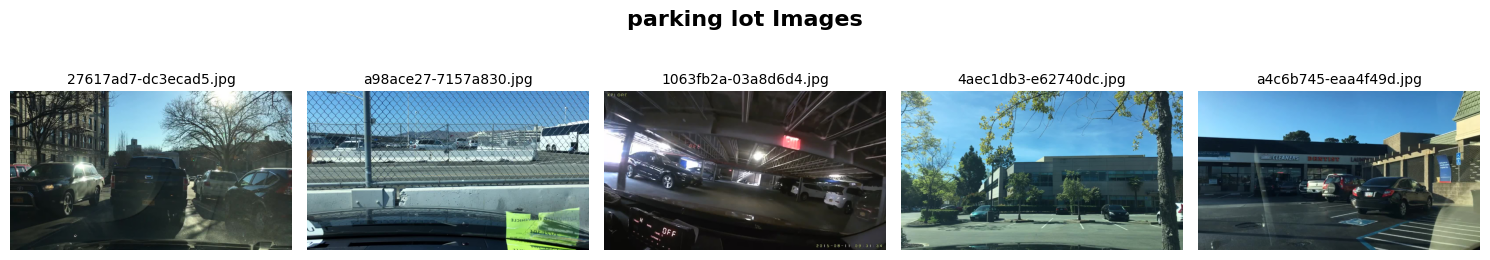

In [ ]:
# Define outlier thresholds
filtering_criteria  = "parking lot"
filtered_df = img_df[img_df["image_scene"] == filtering_criteria]

# Display outlier images
print(f"Number of filtered images: {len(filtered_df)}")
filtered_images = filtered_df["image_path"].unique()

total_imgs_to_show = 5
if len(filtered_images) > total_imgs_to_show:
    filtered_images = np.random.choice(filtered_images, total_imgs_to_show, replace=False)

display_images(filtered_images, title="parking lot Images", num_cols=5)

Number of filtered images: 156


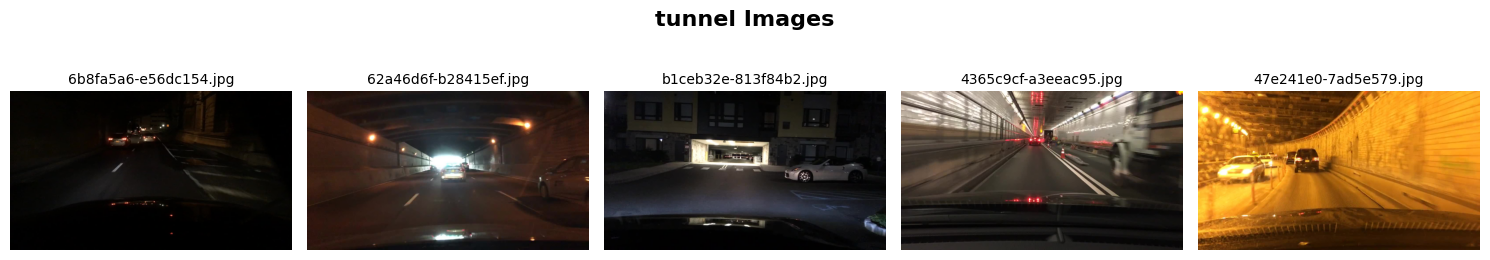

In [129]:
# Define outlier thresholds
filtering_criteria  = "tunnel"
filtered_df = img_df[img_df["image_scene"] == filtering_criteria]

# Display outlier images
print(f"Number of filtered images: {len(filtered_df)}")
filtered_images = filtered_df["image_path"].unique()

total_imgs_to_show = 5
if len(filtered_images) > total_imgs_to_show:
    filtered_images = np.random.choice(filtered_images, total_imgs_to_show, replace=False)

display_images(filtered_images, title="tunnel Images", num_cols=5)

Number of filtered images: 414


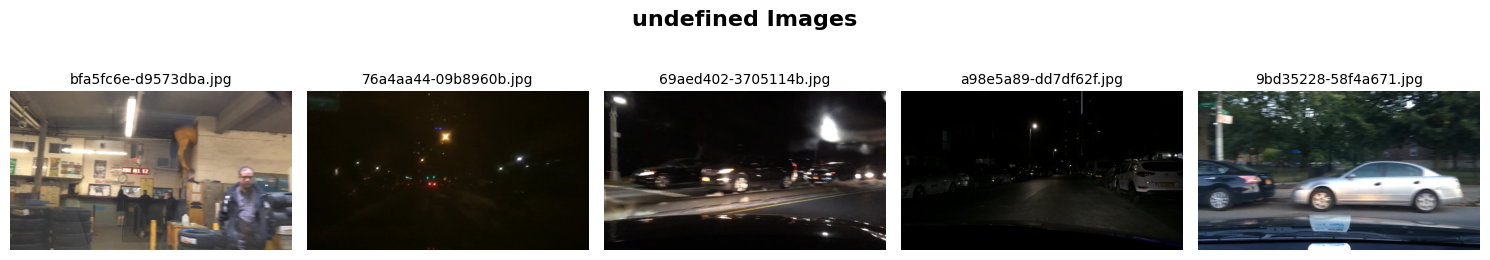

In [128]:
# Define outlier thresholds
filtering_criteria  = "undefined"
filtered_df = img_df[img_df["image_scene"] == filtering_criteria]

# Display outlier images
print(f"Number of filtered images: {len(filtered_df)}")
filtered_images = filtered_df["image_path"].unique()

total_imgs_to_show = 5
if len(filtered_images) > total_imgs_to_show:
    filtered_images = np.random.choice(filtered_images, total_imgs_to_show, replace=False)

display_images(filtered_images, title="undefined Images", num_cols=5)

### Image timeofday

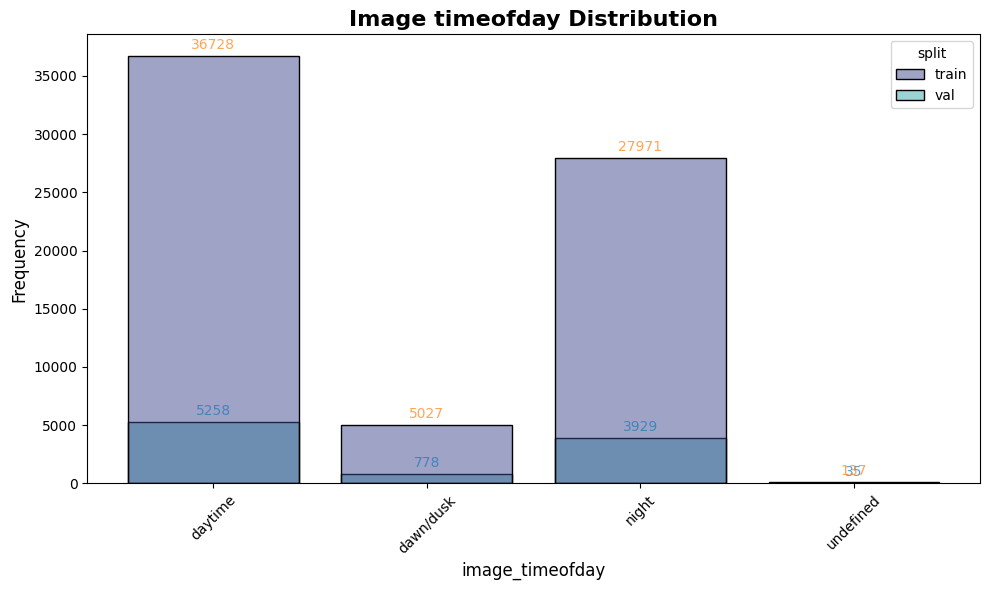

In [130]:

plt.figure(figsize=(10, 6))

ax = sns.histplot(data=img_df, x="image_timeofday",hue="split", shrink=0.8, palette="mako", kde=False)
for container, hue_value in zip(ax.containers, img_df["split"].unique()):
    ax.bar_label(container, fmt='%d', label_type='edge', fontsize=10, padding=3, color=sns.color_palette("tab10")[list(img_df["split"].unique()).index(hue_value)], alpha=0.7)

ax.set_title("Image timeofday Distribution", fontsize=16, fontweight='bold')
ax.set_xlabel("image_timeofday", fontsize=12)
ax.set_ylabel("Frequency", fontsize=12)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

#### check image time images

Number of filtered images: 5805


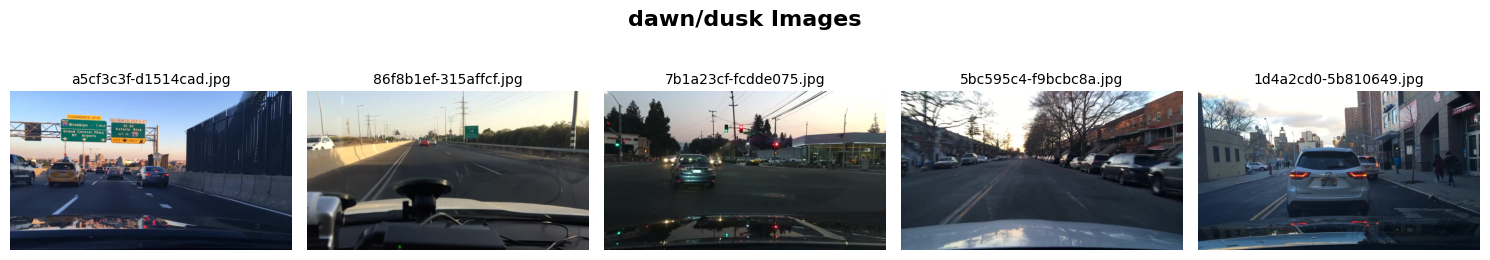

In [131]:
# Define outlier thresholds
filtering_criteria  = "dawn/dusk"
filtered_df = img_df[img_df["image_timeofday"] == filtering_criteria]

# Display outlier images
print(f"Number of filtered images: {len(filtered_df)}")
filtered_images = filtered_df["image_path"].unique()

total_imgs_to_show = 5
if len(filtered_images) > total_imgs_to_show:
    filtered_images = np.random.choice(filtered_images, total_imgs_to_show, replace=False)

display_images(filtered_images, title="dawn/dusk Images", num_cols=5)

### Image scene Distribution wrt to timeofday

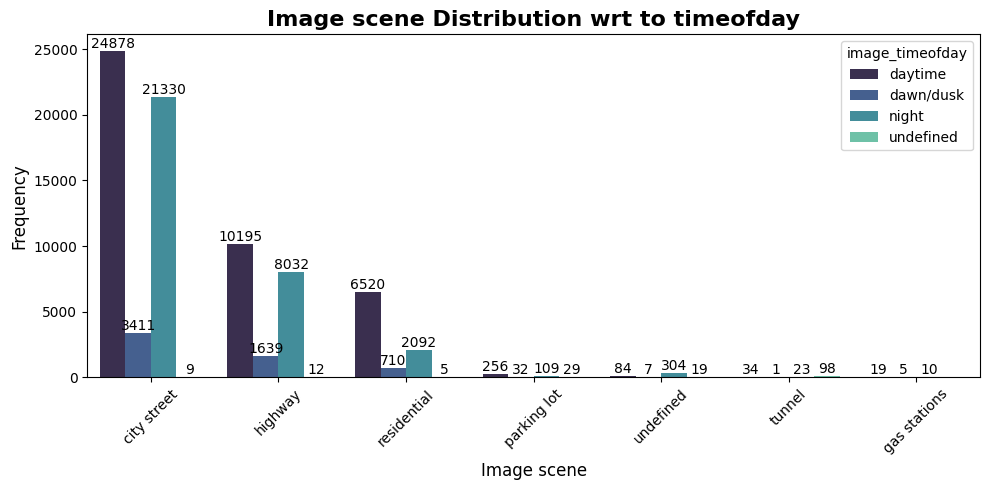

In [132]:
plt.figure(figsize=(10,5))

ax = sns.countplot(data = img_df,x="image_scene", hue = "image_timeofday",palette="mako" )
for i in ax.containers:
    ax.bar_label(i,)
    
ax.set_title("Image scene Distribution wrt to timeofday", fontsize=16, fontweight='bold')
ax.set_xlabel("Image scene", fontsize=12)
ax.set_ylabel("Frequency", fontsize=12)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

1. The data is unevenly distibuted for image scene. We have very less number of samples for parking lot, tunnel and gas station.
2. We have approx. 400 images where image scene is not labeled
3. Image time duration distribution proportionally distributed among different image scenes

## Annotation analysis

In [4]:
def plot_bboxes_with_categories(df, image_column="image_path", category_column="category",title = "Images", num_cols=3, num_rows=2):
    """
    Plot bounding boxes and category names on images with fixed colors based on class.

    Parameters:
    - image_df: DataFrame containing image metadata.
    - df: DataFrame containing annotation data with bounding box coordinates and categories.
    - image_column: Column in `image_df` that contains the image paths.
    - category_column: Column in `df` that contains the category names.
    - img_dir: Directory where images are stored (optional if `image_column` contains full paths).
    - num_cols: Number of images per row.
    - num_rows: Number of rows of images to display.
    """
    # Get unique categories and assign fixed colors
    unique_categories = df[category_column].unique()
    color_palette = sns.color_palette("hsv", len(unique_categories))
    category_colors = {category: color for category, color in zip(unique_categories, color_palette)}

    # Select images to display
    num_images = num_cols * num_rows
    selected_images = np.random.choice(df[image_column].unique(), num_images, replace=False) 

    # Create a grid for displaying images
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, num_rows * 5))
    axes = axes.flatten()

    for idx, image_path in enumerate(selected_images):
        # Load the image
        
        img = plt.imread(image_path)

        # Plot the image
        ax = axes[idx]
        ax.imshow(img)
        ax.axis("off")

        # Get annotations for the current image
        image_annotations = df[df[image_column] == image_path]

        # Plot bounding boxes and category names
        for _, row in image_annotations.iterrows():
            x1, y1, x2, y2 = row["x1"], row["y1"], row["x2"], row["y2"]
            category = row[category_column]
            color = category_colors[category]

            # Draw the bounding box
            ax.add_patch(plt.Rectangle((x1, y1), x2 - x1, y2 - y1, edgecolor=color, facecolor="none", linewidth=2))

            # Add category name
            ax.text(x1, y1 - 5, category, color=color, fontsize=10, bbox=dict(facecolor="white", alpha=0.2, edgecolor="none"))

        ax.set_title(f"{os.path.basename(image_path)}", fontsize=10)

    # Hide any unused axes
    for idx in range(len(selected_images), len(axes)):
        axes[idx].axis("off")

    plt.suptitle(title, fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [ ]:
train_anno_csv = "./data/train/object_detection_annotations.csv"
val_anno_csv = "./data/val/object_detection_annotations.csv"

train_anno_df = pd.read_csv(train_anno_csv)
train_anno_df["split"] = "train"
val_anno_df = pd.read_csv(val_anno_csv)
val_anno_df["split"] = "val"
print("train_anno_df.shape", train_anno_df.shape)
print("val_anno_df.shape", val_anno_df.shape)
anno_df = pd.concat([train_anno_df,val_anno_df],axis=0)
print("anno_df.shape", anno_df.shape)

anno_df.head()

train_anno_df.shape (1286871, 10)
val_anno_df.shape (185526, 10)
anno_df.shape (1472397, 10)


,image_name,category,x1,y1,x2,y2,occluded,truncated,trafficLightColor,split
0,0000f77c-6257be58.jpg,traffic light,1125.902264,133.184488,1156.978645,210.875445,False,False,green,train
1,0000f77c-6257be58.jpg,traffic light,1156.978645,136.637417,1191.507960,210.875443,False,False,green,train
2,0000f77c-6257be58.jpg,traffic sign,1101.731743,211.122087,1170.790370,233.566141,False,False,none,train
3,0000f77c-6257be58.jpg,traffic sign,0.000000,0.246631,100.381647,122.825696,False,True,none,train
4,0000f77c-6257be58.jpg,car,45.240919,254.530367,357.805838,487.906215,False,False,none,train


In [6]:
anno_df.category.unique()

array(['traffic light', 'traffic sign', 'car', 'person', 'bus', 'truck',
       'rider', 'bike', 'motor', 'train'], dtype=object)

### Feature engineering

In [166]:

anno_df["bbox_w"] = anno_df["x2"] - anno_df["x1"]
anno_df["bbox_h"] = anno_df["y2"] - anno_df["y1"]
anno_df["bbox_area"] = anno_df["bbox_w"] * anno_df["bbox_h"]


#### combining img info

In [167]:
# Merge anno_df and img_df on the 'image_name' column
anno_df = pd.merge(anno_df, img_df.drop("split",axis=1), on="image_name", how="inner")
anno_df.head(2)

,image_name,category,x1,y1,x2,y2,occluded,truncated,trafficLightColor,split,...,brightness,sharpness,contrast,rgb_mean,rgb_std,size(MBs),image_weather,image_scene,image_timeofday,image_path
0,0000f77c-6257be58.jpg,traffic light,1125.902264,133.184488,1156.978645,210.875445,False,False,green,train,...,105.935394,6.303803,62.919911,"[109.34247287326389, 109.04203016493055, 96.43...","[64.66566020112917, 63.9676658242913, 62.25361...",0.0712,clear,city street,daytime,D:\self\projects\submission_aman_gupta\submiss...
1,0000f77c-6257be58.jpg,traffic light,1156.978645,136.637417,1191.507960,210.875443,False,False,green,train,...,105.935394,6.303803,62.919911,"[109.34247287326389, 109.04203016493055, 96.43...","[64.66566020112917, 63.9676658242913, 62.25361...",0.0712,clear,city street,daytime,D:\self\projects\submission_aman_gupta\submiss...


In [168]:
anno_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1472397 entries, 0 to 1472396
Data columns (total 25 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   image_name         1472397 non-null  object 
 1   category           1472397 non-null  object 
 2   x1                 1472397 non-null  float64
 3   y1                 1472397 non-null  float64
 4   x2                 1472397 non-null  float64
 5   y2                 1472397 non-null  float64
 6   occluded           1472397 non-null  bool   
 7   truncated          1472397 non-null  bool   
 8   trafficLightColor  1472397 non-null  object 
 9   split              1472397 non-null  object 
 10  bbox_w             1472397 non-null  float64
 11  bbox_h             1472397 non-null  float64
 12  bbox_area          1472397 non-null  float64
 13  image_width        1472397 non-null  int64  
 14  image_height       1472397 non-null  int64  
 15  brightness         1472397 non-n

In [169]:
anno_df.describe()

,x1,y1,x2,y2,bbox_w,bbox_h,bbox_area,image_width,image_height,brightness,sharpness,contrast,size(MBs)
count,1.472397e+06,1.472397e+06,1.472397e+06,1.472397e+06,1.472397e+06,1.472397e+06,1.472397e+06,1472397.0,1472397.0,1.472397e+06,1.472397e+06,1.472397e+06,1.472397e+06
mean,5.624127e+02,3.014063e+02,6.189523e+02,3.512809e+02,5.653966e+01,4.987464e+01,6.764282e+03,1280.0,720.0,7.764203e+01,4.446485e+00,5.158503e+01,5.813684e-02
std,2.870945e+02,9.373353e+01,2.924577e+02,1.071237e+02,7.558294e+01,6.163229e+01,2.279634e+04,0.0,0.0,3.753065e+01,2.227553e+00,1.607960e+01,1.783448e-02
min,0.000000e+00,0.000000e+00,1.972998e+00,3.638348e+00,1.054950e-01,1.654980e-01,8.714117e-01,1280.0,720.0,2.379336e-01,8.323421e-02,3.718682e+00,1.620000e-02
25%,3.732319e+02,2.495508e+02,4.214499e+02,2.864843e+02,1.687499e+01,1.713855e+01,3.047444e+02,1280.0,720.0,3.877932e+01,2.554181e+00,3.829078e+01,4.320000e-02
50%,5.656617e+02,3.071970e+02,6.014175e+02,3.503718e+02,2.869834e+01,2.909387e+01,8.164792e+02,1280.0,720.0,9.004186e+01,4.365927e+00,5.625662e+01,5.830000e-02
75%,7.436614e+02,3.606009e+02,7.929111e+02,4.135195e+02,6.019939e+01,5.524063e+01,3.014693e+03,1280.0,720.0,1.061027e+02,6.086426e+00,6.370689e+01,7.160000e-02
max,1.279178e+03,7.155113e+02,1.280000e+03,7.200000e+02,1.279269e+03,7.198896e+02,9.177098e+05,1280.0,720.0,2.503836e+02,2.009802e+01,9.325821e+01,1.439000e-01


### Category counts

C:\Users\AmanGupta\AppData\Local\Temp\ipykernel_15460\3324160276.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=anno_df, x="category", palette="mako", order=anno_df["category"].value_counts().index)


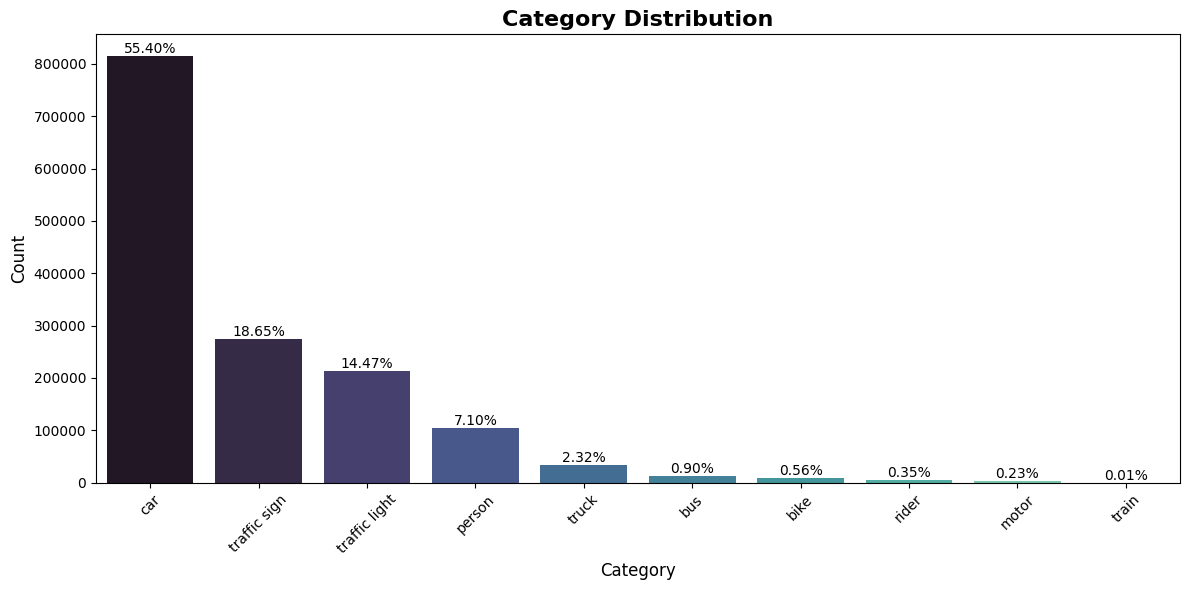

In [85]:
plt.figure(figsize=(12, 6))
ax = sns.countplot(data=anno_df, x="category", palette="mako", order=anno_df["category"].value_counts().index)

# Annotate bars with percentages
total = len(anno_df)
for container in ax.containers:
    ax.bar_label(container, labels=[f'{(v.get_height() / total * 100):.2f}%' for v in container], label_type='edge', fontsize=10)

# Set titles and labels
ax.set_title("Category Distribution", fontsize=16, fontweight='bold')
ax.set_xlabel("Category", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

1. We have very less number of samples for train
2. Truck, Bus, bike, rider, motor and train contributes less than 5% of total annotations.

#### show images having bus

Number of filtered images: 13269


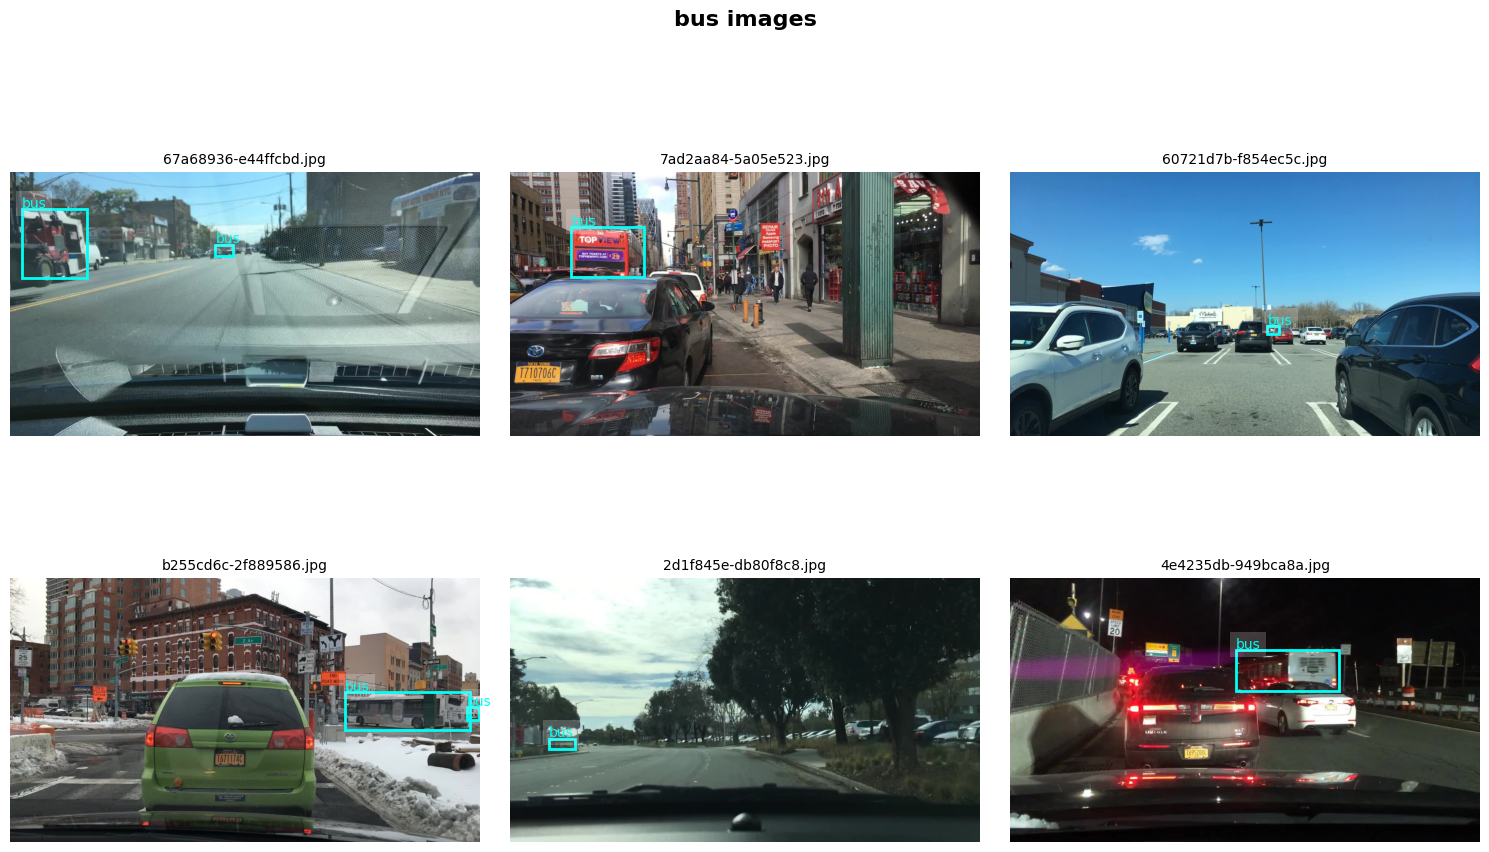

In [173]:
filtering_criteria  = "bus"
filtered_df = anno_df[anno_df["category"] == filtering_criteria]
print(f"Number of filtered images: {len(filtered_df)}")
plot_bboxes_with_categories(filtered_df, image_column="image_path", category_column="category",title="bus images", num_cols=3, num_rows=2)

### Unique image count with respect to each category type

C:\Users\AmanGupta\AppData\Local\Temp\ipykernel_15460\22059081.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=unique_image_counts.index, y=unique_image_counts.values, palette="mako")


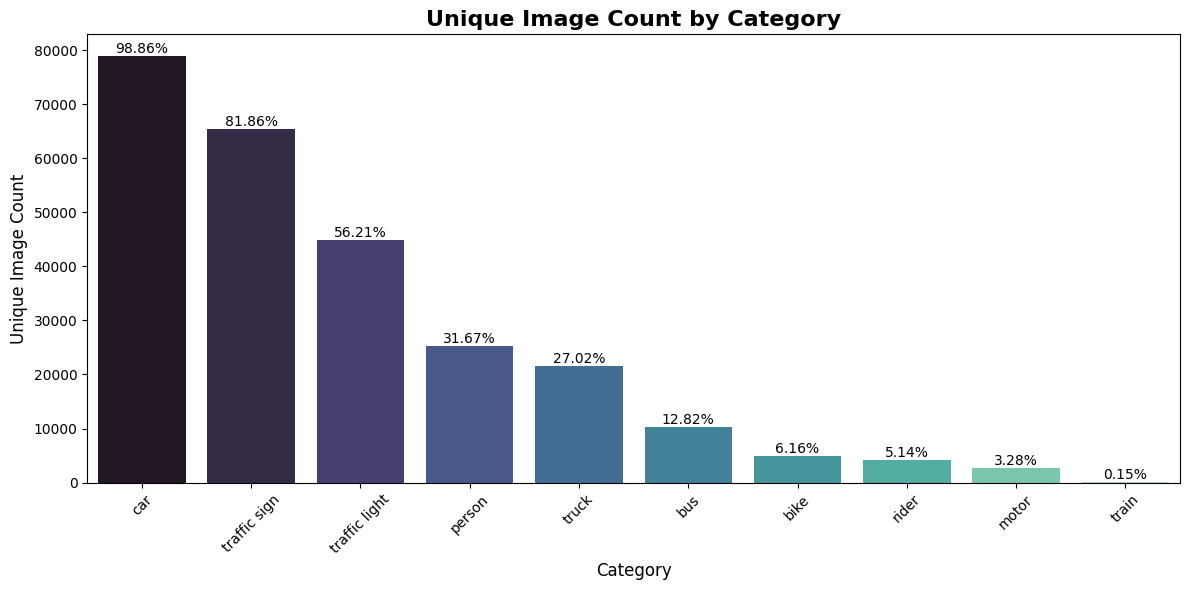

In [92]:
plt.figure(figsize=(12, 6))

# Count unique images per category
unique_image_counts = anno_df.groupby('category')['image_name'].nunique().sort_values(ascending=False)

# Plot the data
ax = sns.barplot(x=unique_image_counts.index, y=unique_image_counts.values, palette="mako")

total_unique_images = len(anno_df['image_name'].unique())
# Annotate bars with counts
for container in ax.containers:
    # Use the height of each bar to label it
    for bar in container:
        height = bar.get_height()
        # ax.text(bar.get_x() + bar.get_width() / 2, height, f'{int(height)}', ha='center', va='bottom', fontsize=10)
        ax.text(bar.get_x() + bar.get_width() / 2, height, f'{(height / total_unique_images * 100):.2f}%', ha='center', va='bottom', fontsize=10,)

# Set titles and labels
ax.set_title("Unique Image Count by Category", fontsize=16, fontweight='bold')
ax.set_xlabel("Category", fontsize=12)
ax.set_ylabel("Unique Image Count", fontsize=12)
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

1. Total images are significantly less for bike,rider,motor and train, contributing in less than 15% of images combined


### Check annotation heights wrt different categories

C:\Users\AmanGupta\AppData\Local\Temp\ipykernel_15460\2893333034.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=anno_df, x="category", y="bbox_h", palette="mako")
C:\Users\AmanGupta\AppData\Local\Temp\ipykernel_15460\2893333034.py:10: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


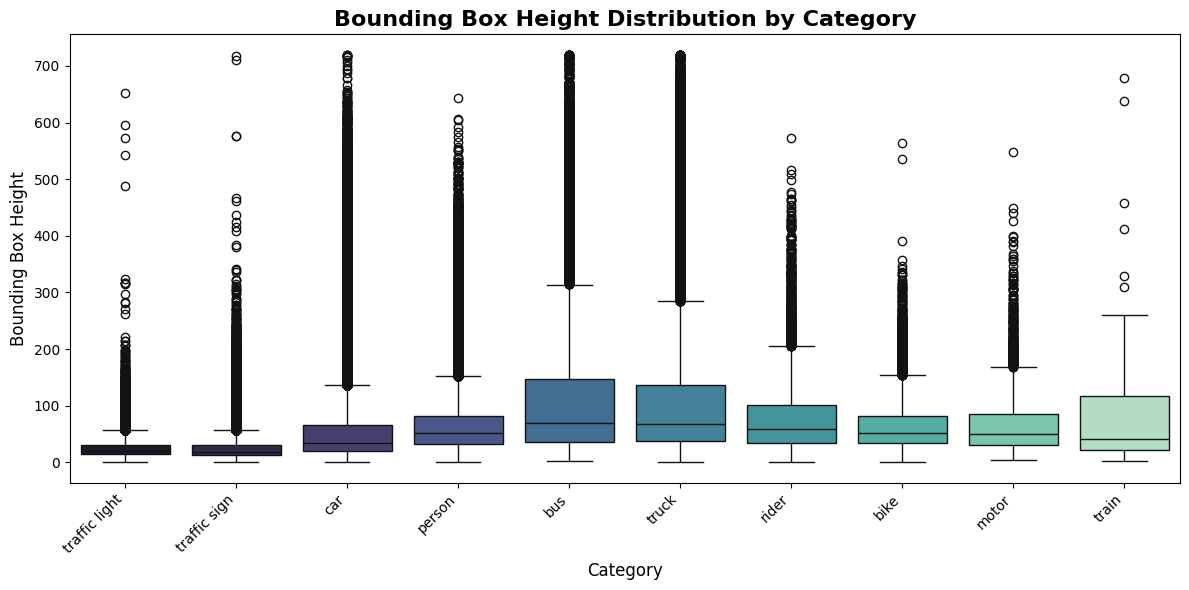

In [93]:
plt.figure(figsize=(12, 6))
ax = sns.boxplot(data=anno_df, x="category", y="bbox_h", palette="mako")

# Add labels and title
ax.set_title("Bounding Box Height Distribution by Category", fontsize=16, fontweight='bold')
ax.set_xlabel("Category", fontsize=12)
ax.set_ylabel("Bounding Box Height", fontsize=12)

# Rotate x-axis labels for better readability
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

C:\Users\AmanGupta\AppData\Local\Temp\ipykernel_15460\2120674279.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=anno_df, x="category", y="bbox_w", palette="mako")
C:\Users\AmanGupta\AppData\Local\Temp\ipykernel_15460\2120674279.py:10: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=10)


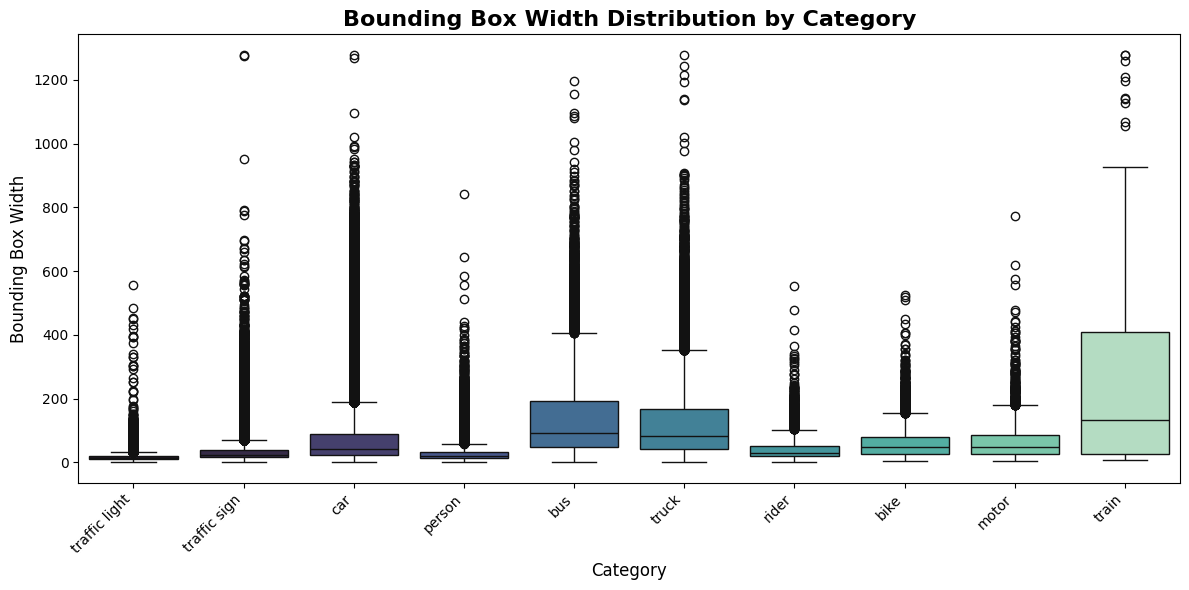

In [95]:
plt.figure(figsize=(12, 6))
ax = sns.boxplot(data=anno_df, x="category", y="bbox_w", palette="mako")

# Add a title and labels
ax.set_title("Bounding Box Width Distribution by Category", fontsize=16, fontweight='bold')
ax.set_xlabel("Category", fontsize=12)
ax.set_ylabel("Bounding Box Width", fontsize=12)

# Rotate x-axis labels for better readability
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=10)

# Adjust layout for better spacing
plt.tight_layout()
plt.show()

C:\Users\AmanGupta\AppData\Local\Temp\ipykernel_15460\319682133.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=anno_df, x="category", y="bbox_area", palette="mako")
C:\Users\AmanGupta\AppData\Local\Temp\ipykernel_15460\319682133.py:10: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=10)


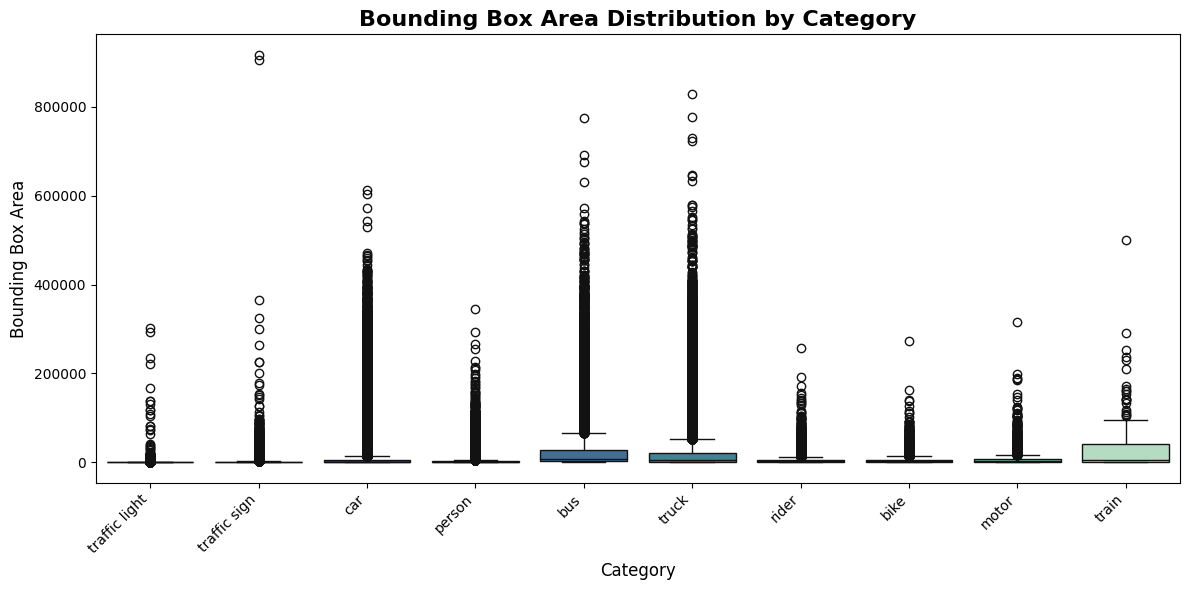

In [96]:
plt.figure(figsize=(12, 6))
ax = sns.boxplot(data=anno_df, x="category", y="bbox_area", palette="mako")

# Add a title and labels
ax.set_title("Bounding Box Area Distribution by Category", fontsize=16, fontweight='bold')
ax.set_xlabel("Category", fontsize=12)
ax.set_ylabel("Bounding Box Area", fontsize=12)

# Rotate x-axis labels for better readability
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=10)

# Adjust layout for better spacing
plt.tight_layout()
plt.show()

C:\Users\AmanGupta\AppData\Local\Temp\ipykernel_15460\4244042043.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=mean_bbox_h.index, y=mean_bbox_h.values, palette="mako",order=order)
C:\Users\AmanGupta\AppData\Local\Temp\ipykernel_15460\4244042043.py:13: UserWarning: FixedFormatter should only be used together with FixedLocator
  _ = ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


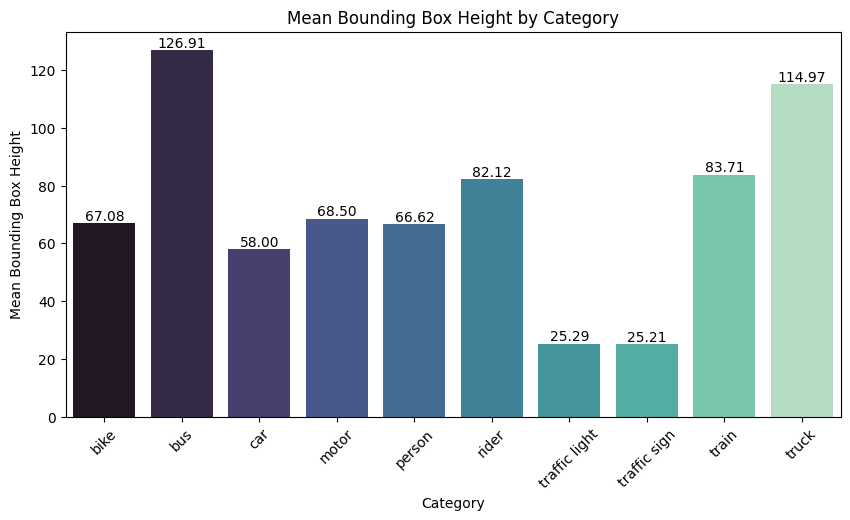

In [101]:
mean_bbox_h = anno_df.groupby('category')['bbox_h'].mean()
order = sorted(mean_bbox_h.index)
plt.figure(figsize=(10, 5))
ax = sns.barplot(x=mean_bbox_h.index, y=mean_bbox_h.values, palette="mako",order=order)

# Annotate bars with mean values
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', label_type='edge', fontsize=10)

ax.set_title("Mean Bounding Box Height by Category")
ax.set_xlabel("Category")
ax.set_ylabel("Mean Bounding Box Height")
_ = ax.set_xticklabels(ax.get_xticklabels(), rotation=45)

1. Traffic sign and traffic light has small bbox as compared to other classes.
2. Truck and bus as comparitively large bboxes. We need to be carefully in choosing anchor size in models.

C:\Users\AmanGupta\AppData\Local\Temp\ipykernel_15460\1286861705.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.countplot(data=anno_df, x="occluded", palette="mako")
C:\Users\AmanGupta\AppData\Local\Temp\ipykernel_15460\1286861705.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.countplot(data=anno_df, x="truncated", palette="mako")


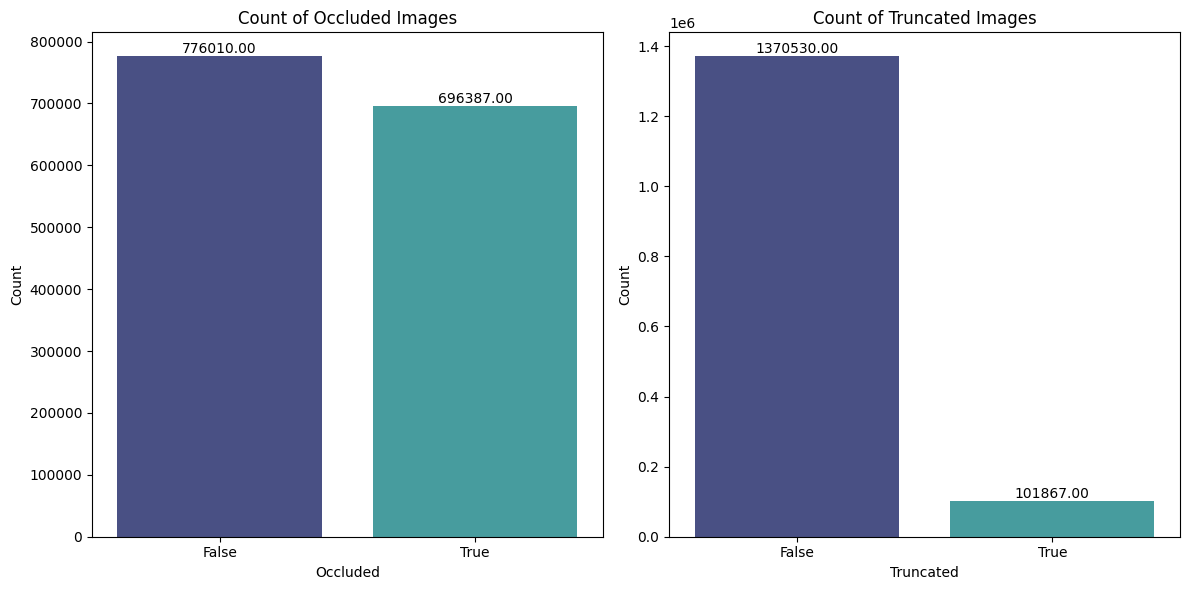

In [103]:
plt.figure(figsize=(12, 6))

# Countplot for occluded images
plt.subplot(1, 2, 1)
ax1 = sns.countplot(data=anno_df, x="occluded", palette="mako")

# Annotate bars with mean values
for container in ax1.containers:
    ax1.bar_label(container, fmt='%.2f', label_type='edge', fontsize=10)

plt.title("Count of Occluded Images")
plt.xlabel("Occluded")
plt.ylabel("Count")

# Countplot for truncated images
plt.subplot(1, 2, 2)
ax2 = sns.countplot(data=anno_df, x="truncated", palette="mako")
# Annotate bars with mean values
for container in ax2.containers:
    ax2.bar_label(container, fmt='%.2f', label_type='edge', fontsize=10)

plt.title("Count of Truncated Images")
plt.xlabel("Truncated")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

1. Large number of oclluded cases

C:\Users\AmanGupta\AppData\Local\Temp\ipykernel_15460\957087794.py:9: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=10)


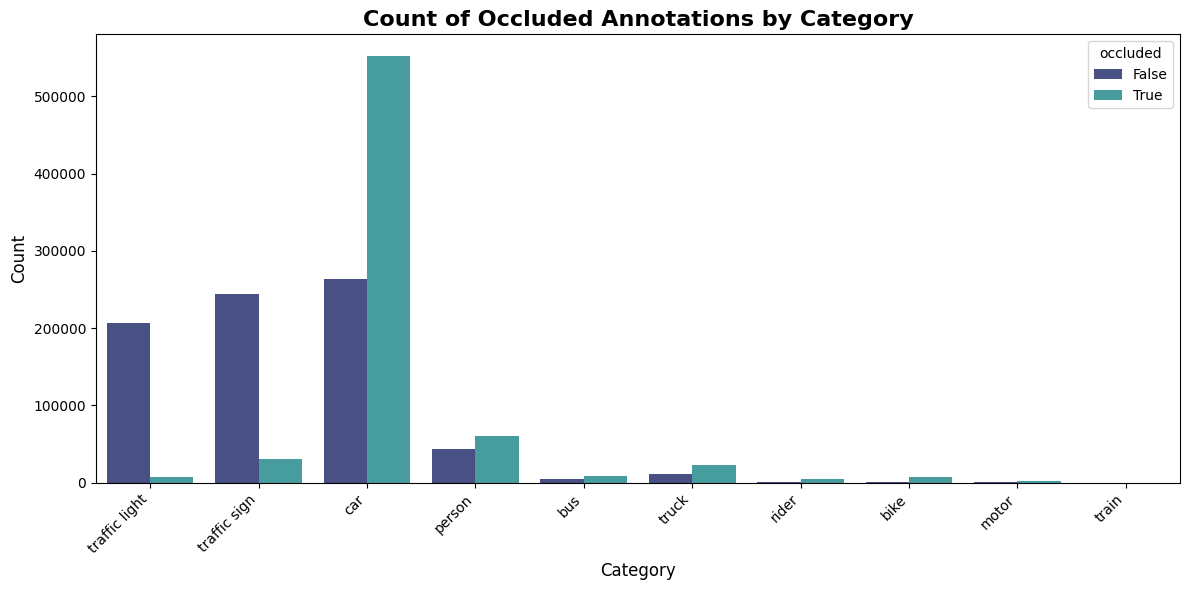

In [156]:
plt.figure(figsize=(12, 6))
ax = sns.countplot(data=anno_df, x="category", hue="occluded", palette="mako")
# # Add a title and labels
ax.set_title("Count of Occluded Annotations by Category", fontsize=16, fontweight='bold')
ax.set_xlabel("Category", fontsize=12)
ax.set_ylabel("Count", fontsize=12)

# Rotate x-axis labels for better readability
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=10)

plt.tight_layout()
plt.show()

1. very large number of cars are occluded

#### plot car which are occluded

Number of filtered images: 552503


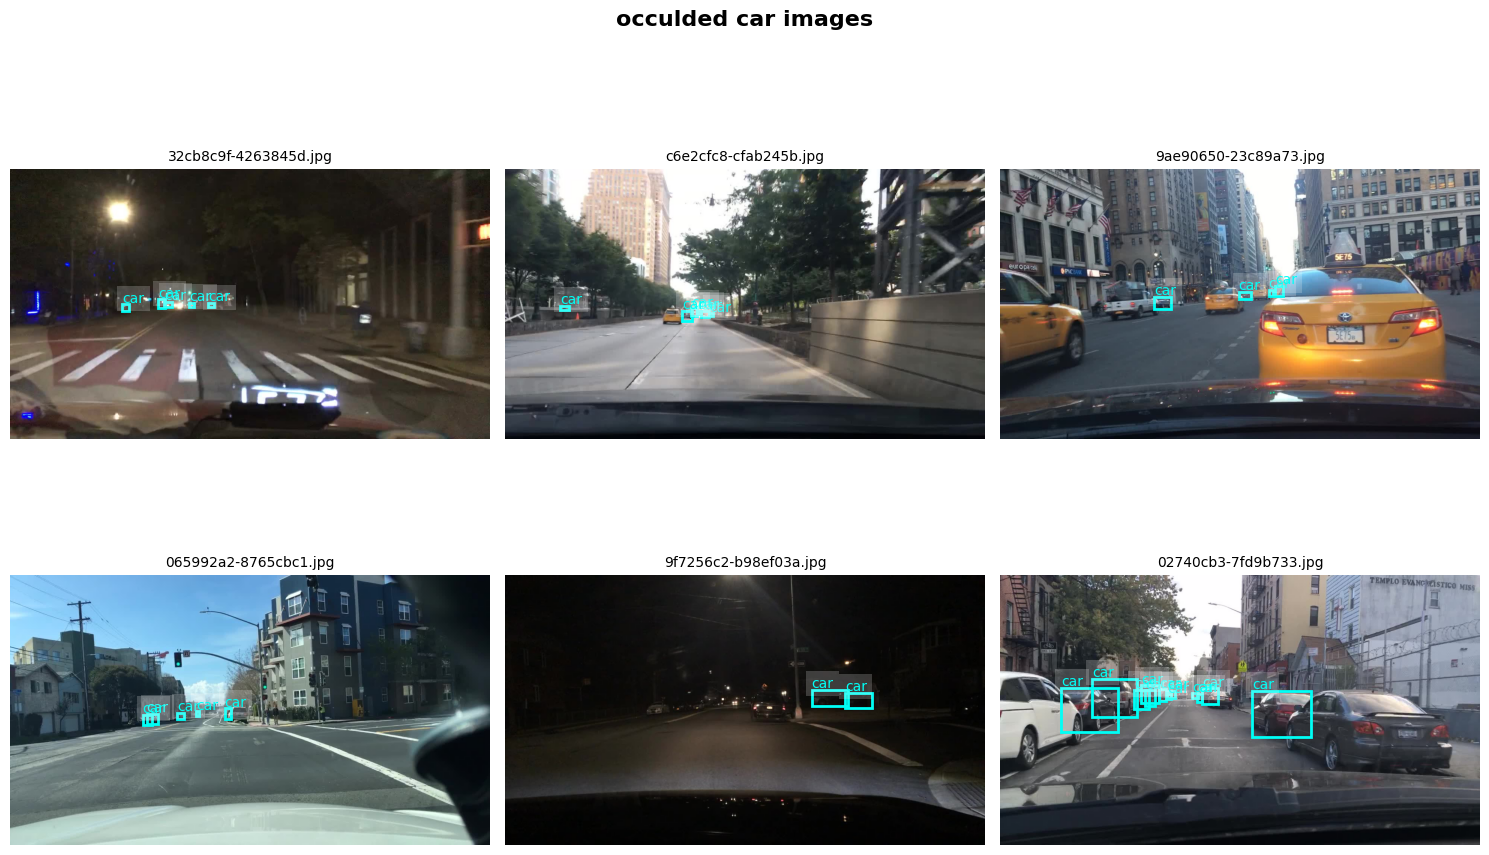

In [174]:
filtering_criteria  = "car"
filtered_df = anno_df[(anno_df["category"] == filtering_criteria) & (anno_df["occluded"] == 1)]
print(f"Number of filtered images: {len(filtered_df)}")
plot_bboxes_with_categories(filtered_df, image_column="image_path", category_column="category",title="occulded car images", num_cols=3, num_rows=2)

C:\Users\AmanGupta\AppData\Local\Temp\ipykernel_15460\3998199695.py:10: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=10)


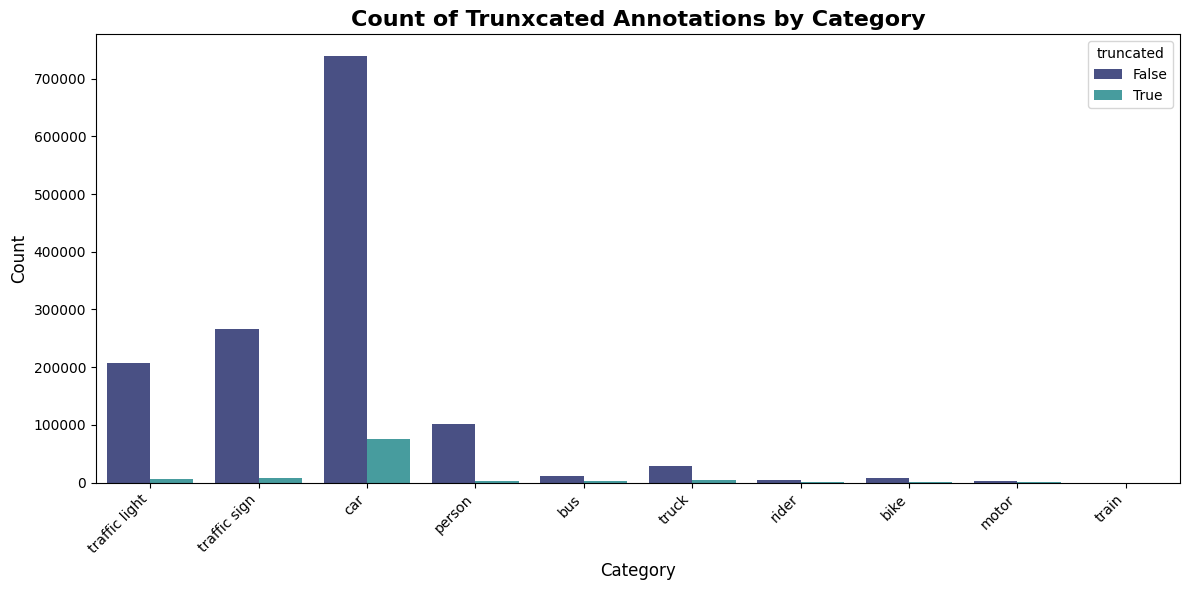

In [ ]:
plt.figure(figsize=(12, 6))
ax = sns.countplot(data=anno_df, x="category", hue="truncated", palette="mako")

# # Add a title and labels
ax.set_title("Count of Truncated Annotations by Category", fontsize=16, fontweight='bold')
ax.set_xlabel("Category", fontsize=12)
ax.set_ylabel("Count", fontsize=12)

# Rotate x-axis labels for better readability
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=10)

plt.tight_layout()
plt.show()

1. Mostly cars are truncated

#### plot cars which are truncated

Number of filtered images: 76009


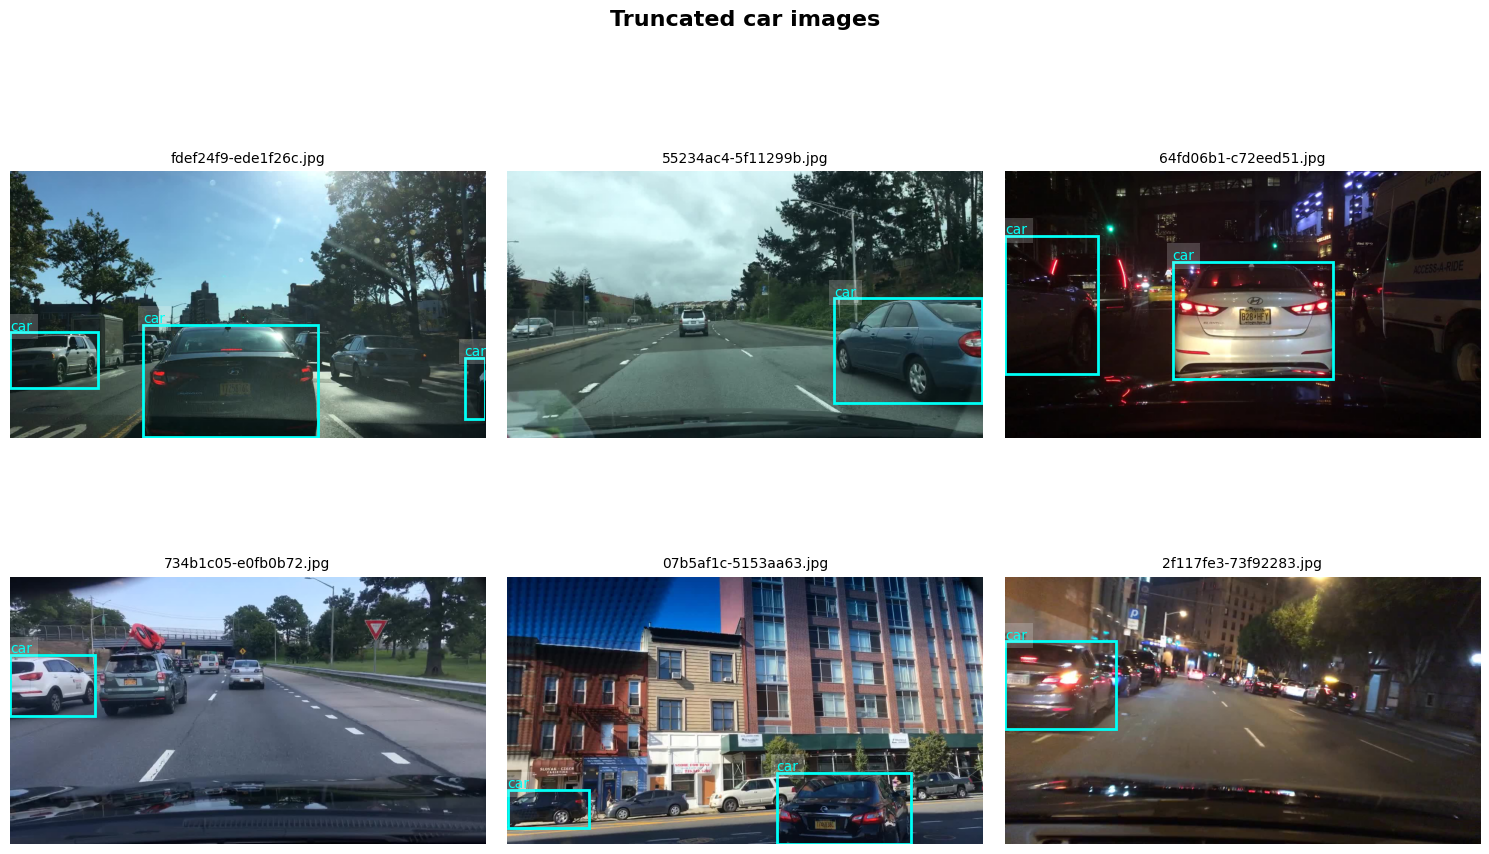

In [ ]:
filtering_criteria  = "car"
filtered_df = anno_df[(anno_df["category"] == filtering_criteria) & (anno_df["truncated"] == 1)]
print(f"Number of filtered images: {len(filtered_df)}")
plot_bboxes_with_categories(filtered_df, image_column="image_path", category_column="category",title="Truncated car images",num_cols=3, num_rows=2)